In [1]:
from pathlib import Path
from src import config
import cv2
import numpy as np
from src.court_detector import CourtDetector
from src.utils.helpers import crop_center_img, load_process_params
from src.config import set_debug_mode, get_debug_mode
from cvgeomkit.utils.helpers import read_image_as_numpyimage, load_json
from cvgeomkit.utils.plotting import display_img

In [2]:
get_debug_mode()
set_debug_mode(True)

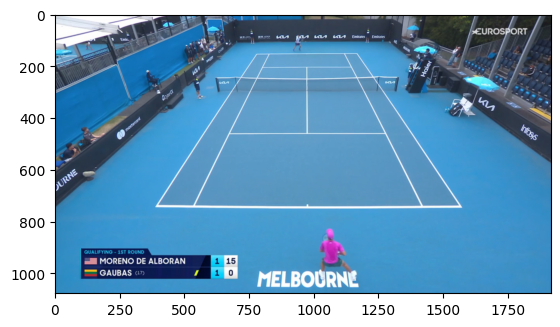

In [3]:
path = '../data/pics/06_03.png'
# path = '../data/pics/skip/skip_01_35.png'
img = read_image_as_numpyimage(path)
display_img(img)

#### scan for baseline

In [4]:
params = load_process_params('../config/process_params.config.json')

crop_center_ratio = params.detection_params.basic.crop_center_ratio
roi_h_px = params.detection_params.basic.roi_h_px
step_px = params.detection_params.basic.step_px

warmup = params.detection_params.baseline.warmup
canny_lower_thresh = params.detection_params.baseline.canny_lower_thresh
canny_upper_thresh = params.detection_params.baseline.canny_upper_thresh
hough_thresh = params.detection_params.baseline.hough_thresh
min_line_len_ratio = params.detection_params.baseline.min_line_len_ratio
min_line_gap_px = params.detection_params.baseline.min_line_gap_px
h_line_slope_tolerance = params.detection_params.baseline.h_line_slope_tolerance

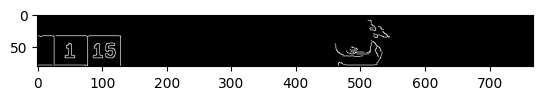

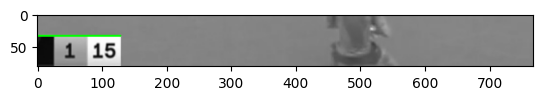

lines
[y = 0.0 * x + 33.0]
baseline candidates
[y = 0.0 * x + 33.0]


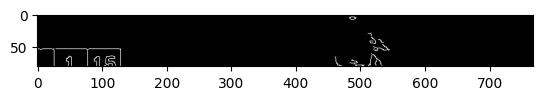

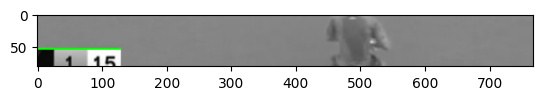

lines
[y = 0.0 * x + 53.0]
baseline candidates
[y = 0.0 * x + 53.0]


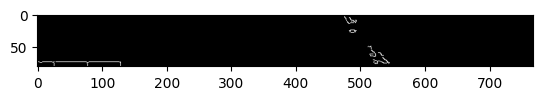

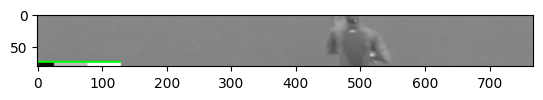

lines
[y = 0.0 * x + 73.0]
baseline candidates
[y = 0.0 * x + 73.0]


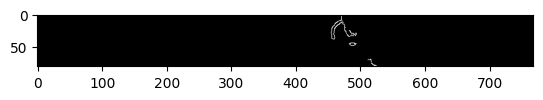

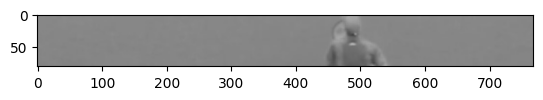

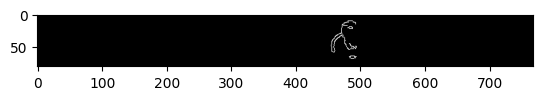

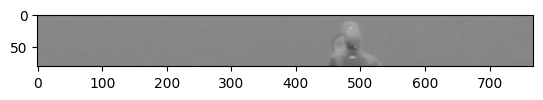

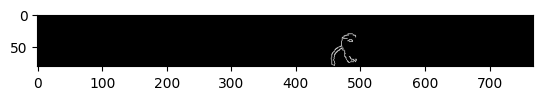

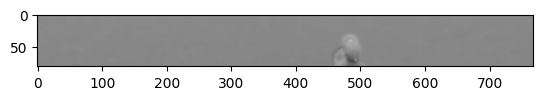

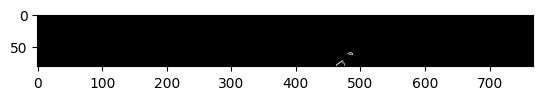

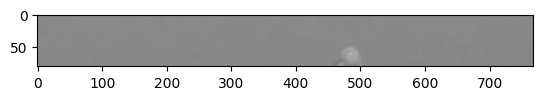

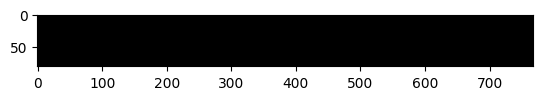

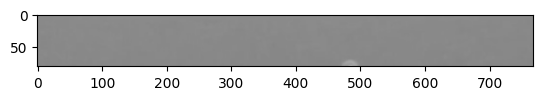

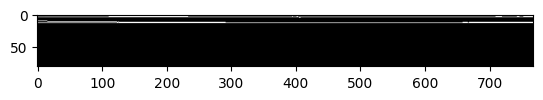

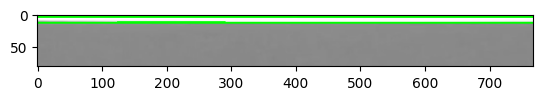

lines
[y = 0.0 * x + 13.0, y = 0.0 * x + 4.0, y = 0.0 * x + 12.0, y = 0.0 * x + 3.0]
baseline candidates
[y = 0.0 * x + 13.0, y = 0.0 * x + 4.0, y = 0.0 * x + 12.0, y = 0.0 * x + 3.0]


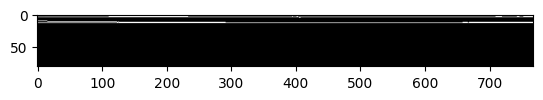

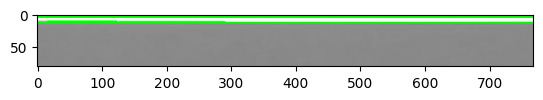

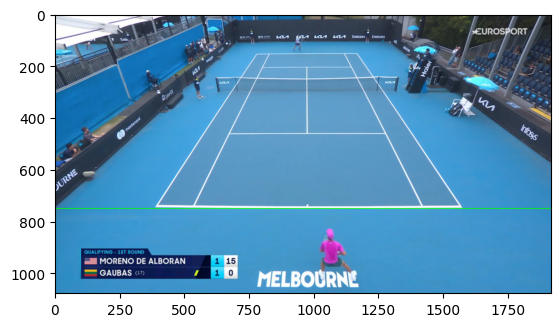

In [5]:
detector = CourtDetector(img, crop_center_ratio, roi_h_px, step_px)
baseline = detector.scan_for_baseline(
    warmup,
    canny_lower_thresh,
    canny_upper_thresh,
    hough_thresh,
    min_line_len_ratio,
    min_line_gap_px,
    h_line_slope_tolerance
)

if baseline is not None:
    p1, p2 = baseline.limit_to_img(img)
    img_copy = img.copy()
    cv2.line(img_copy, p1, p2, (0, 255, 0), 2)
    display_img(img_copy)